In [10]:
import pymysql as sql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## MYSQL connectivity

In [11]:
conn = sql.connect(host = "localhost",user="root",password="",database="Amazone_Sales",port=3307,connect_timeout=600)
cur = conn.cursor()

## Total Orders in State

In [12]:
query = """
SELECT shipping_state , COUNT(order_id) FROM orders GROUP BY shipping_state ORDER BY COUNT(order_id) DESC;
"""
cur.execute(query)
State_Orders = cur.fetchall()
State_Orders = pd.DataFrame(State_Orders,columns=['State','Orders'])
State_Orders

,State,Orders
0,Karnataka,877
1,Telangana,840
2,Kerala,839
3,Rajasthan,837
4,Delhi,818
5,Haryana,815
6,Maharashtra,810
7,Tamil Nadu,809
8,Uttar Pradesh,788
9,West Bengal,786


## Total Orders in City

In [13]:
query = """
            SELECT shipping_city , COUNT(order_id) FROM orders GROUP BY shipping_city ORDER BY COUNT(order_id) DESC;
            """
cur.execute(query)
City_Orders = cur.fetchall()
City_Orders = pd.DataFrame(City_Orders,columns=['City','Orders'])
City_Orders

,City,Orders
0,Chennai,856
1,Mumbai,837
2,Ludhiana,832
3,Hyderabad,821
4,Kochi,816
5,Kolkata,816
6,Ahmedabad,814
7,Delhi,810
8,Bengaluru,804
9,Lucknow,797


## Category Wise Total Orders Quantity

In [14]:
query = """
            SELECT products.category , SUM(order_items.quantity) FROM 
            products JOIN order_items ON products.product_id = order_items.product_id
            GROUP BY products.category
        """
cur.execute(query)
Category_Quantity = cur.fetchall()
Category_Quantity = pd.DataFrame(Category_Quantity,columns=['Category','Order_Quantity'])
Category_Quantity

,Category,Order_Quantity
0,Beauty,6193
1,Books,4432
2,Clothing,5544
3,Electronics,6496
4,Home,5306
5,Sports,6818


## Customer Segment Wise Total Orders

In [15]:
query = """
            SELECT customers.customer_segment , COUNT(orders.order_id) FROM orders JOIN customers 
            ON orders.customer_id = customers.customer_id
            GROUP BY customers.customer_segment
            """
cur.execute(query)
Segment_Orders = cur.fetchall()
Segment_Orders = pd.DataFrame(Segment_Orders,columns=['Customer_Segment','Orders'])
Segment_Orders

,Customer_Segment,Orders
0,Consumer,6506
1,Corporate,1790
2,Home Office,1486


## Total Count of Payment Status 

In [16]:
query = """
            SELECT payment_status , COUNT(payment_id) FROM payments GROUP BY payment_status
            """
cur.execute(query)
PaymentStatus_Count = cur.fetchall()
PaymentStatus_Count = pd.DataFrame(PaymentStatus_Count,columns=['Payment_Status','Total_Payments'])
PaymentStatus_Count

,Payment_Status,Total_Payments
0,Failed,770
1,Paid,7943
2,Pending,647
3,Refunded,422


## Total Count of Paid Payment Method  

In [17]:
query = """
            SELECT payment_method,COUNT(payment_id) FROM payments WHERE payment_status = "Paid"
            GROUP BY payment_method
            """
cur.execute(query)
PaidPayment_Count = cur.fetchall()
PaidPayment_Count = pd.DataFrame(PaidPayment_Count,columns=['Payment_Method','Total_Paid_Payments'])
PaidPayment_Count

,Payment_Method,Total_Paid_Payments
0,COD,1623
1,Credit Card,1590
2,Debit Card,1593
3,Net Banking,1551
4,UPI,1586


## Total Products in Stock

In [18]:
query = """
            SELECT product_name , SUM(stock_quantity) FROM products GROUP BY product_name
            """
cur.execute(query)
Product_Stock = cur.fetchall()
Product_Stock = pd.DataFrame(Product_Stock,columns=['Product','Stock_Quantity'])
Product_Stock

,Product,Stock_Quantity
0,Biography,1424
1,Chair,1931
2,Comics,1596
3,Cookware,3275
4,Cricket Bat,1191
5,Dress,3108
6,Dumbbells,2846
7,Face Wash,3358
8,Football,2700
9,Guide,3242


## Total Count of Products in Each Brand 

In [19]:
query = """
            SELECT brand , COUNT(product_id) FROM products GROUP BY brand
            """
cur.execute(query)
BrandProduct_Count = cur.fetchall()
BrandProduct_Count = pd.DataFrame(BrandProduct_Count,columns=['Brand','Products'])
BrandProduct_Count

,Brand,Products
0,Amazon Basics,48
1,FitPro,52
2,Nova,39
3,TechMax,53
4,UrbanStyle,44
5,Zenix,49


##  Total Count of Returns on Reason 

In [20]:
query = """
            SELECT return_reason , COUNT(return_id) FROM returns GROUP BY return_reason
            """
cur.execute(query)
ReasonReturn_Count = cur.fetchall()
ReasonReturn_Count = pd.DataFrame(ReasonReturn_Count,columns=['Reason','Return_Orders'])
ReasonReturn_Count

,Reason,Return_Orders
0,Changed Mind,138
1,Damaged,143
2,Late Delivery,137
3,Quality Issue,149
4,Wrong Item,137


## Total Count of Return in Year 

In [21]:
query = """
            SELECT YEAR(return_date) as year , COUNT(return_id) FROM returns GROUP BY year
            """
cur.execute(query)
YearReturn_Count = cur.fetchall()
YearReturn_Count = pd.DataFrame(YearReturn_Count,columns=['Year','Return_Orders'])
YearReturn_Count

,Year,Return_Orders
0,2024,327
1,2025,358
2,2026,19


## Total Sales by City 

In [22]:
query = """
            SELECT customers.city , ROUND(SUM(order_items.net_amount)) FROM orders 
            JOIN order_items ON orders.order_id = order_items.order_id
            JOIN customers ON customers.customer_id = orders.customer_id
            GROUP BY customers.city
            """
cur.execute(query)
City_Sales = cur.fetchall()
City_Sales = pd.DataFrame(City_Sales,columns = ['City','Sales'])
City_Sales

,City,Sales
0,Ahmedabad,65052071.0
1,Bengaluru,73682518.0
2,Chennai,64148509.0
3,Delhi,68036485.0
4,Gurugram,60321021.0
5,Hyderabad,58442302.0
6,Jaipur,63189850.0
7,Kochi,67973486.0
8,Kolkata,68302782.0
9,Lucknow,52567334.0


## Sales by Yearly Wise Each State

In [23]:
query = """
            SELECT 
    YEAR(orders.order_date) AS order_year,
    customers.state,
    SUM(order_items.net_amount) OVER (
        PARTITION BY YEAR(orders.order_date) 
        ORDER BY SUM(order_items.net_amount)
    ) AS running_total
FROM orders 
JOIN order_items ON orders.order_id = order_items.order_id
JOIN customers ON customers.customer_id = orders.customer_id
GROUP BY YEAR(orders.order_date), customers.state;

            """
cur.execute(query)
State_yearly_sales = cur.fetchall()
State_yearly_sales = pd.DataFrame(State_yearly_sales,columns=['Years','State','Sales'])
State_yearly_sales

,Years,State,Sales
0,2024,Delhi,646503.78
1,2024,Gujarat,31212.34
2,2024,Haryana,676301.11
3,2024,Karnataka,460198.53
4,2024,Kerala,88857.55
5,2024,Maharashtra,389336.04
6,2024,Punjab,624346.36
7,2024,Rajasthan,608660.96
8,2024,Tamil Nadu,516396.57
9,2024,Telangana,442829.68


## Sales by Product_Category

In [24]:
query = """
            SELECT
            products.category,
            SUM(order_items.net_amount)
            FROM products 
            JOIN order_items ON products.product_id = order_items.product_id
            GROUP BY products.category;

            """

cur.execute(query)
Category_Sales = cur.fetchall()
Category_Sales = pd.DataFrame(Category_Sales,columns=['Product_Category','Sales'])
Category_Sales

,Product_Category,Sales
0,Beauty,1.492892e+08
1,Books,1.046421e+08
2,Clothing,9.109645e+07
3,Electronics,1.521895e+08
4,Home,1.176145e+08
5,Sports,1.417108e+08


In [25]:
query = """
            SELECT products.brand,SUM(order_items.net_amount)
            FROM products JOIN order_items ON products.product_id = order_items.product_id
            GROUP BY products.brand

            """
cur.execute(query)
brand_sales = cur.fetchall()
brand_sales = pd.DataFrame(brand_sales,columns=['Brand','Sales'])
brand_sales

,Brand,Sales
0,Amazon Basics,1.403271e+08
1,FitPro,1.442749e+08
2,Nova,1.064574e+08
3,TechMax,1.236015e+08
4,UrbanStyle,1.149848e+08
5,Zenix,1.268969e+08


In [26]:
query = """
            SELECT YEAR(orders.order_date),SUM(order_items.net_amount)
            FROM orders JOIN order_items ON orders.order_id = order_items.order_id
            GROUP BY YEAR(orders.order_date)
            """
cur.execute(query)
yearly_sales = cur.fetchall()
yearly_sales = pd.DataFrame(yearly_sales,columns=['Year','Sales'])
yearly_sales

,Year,Sales
0,2024,3.751915e+08
1,2025,3.813510e+08


## Sales by Yearly Wise State Represent on Lineplot

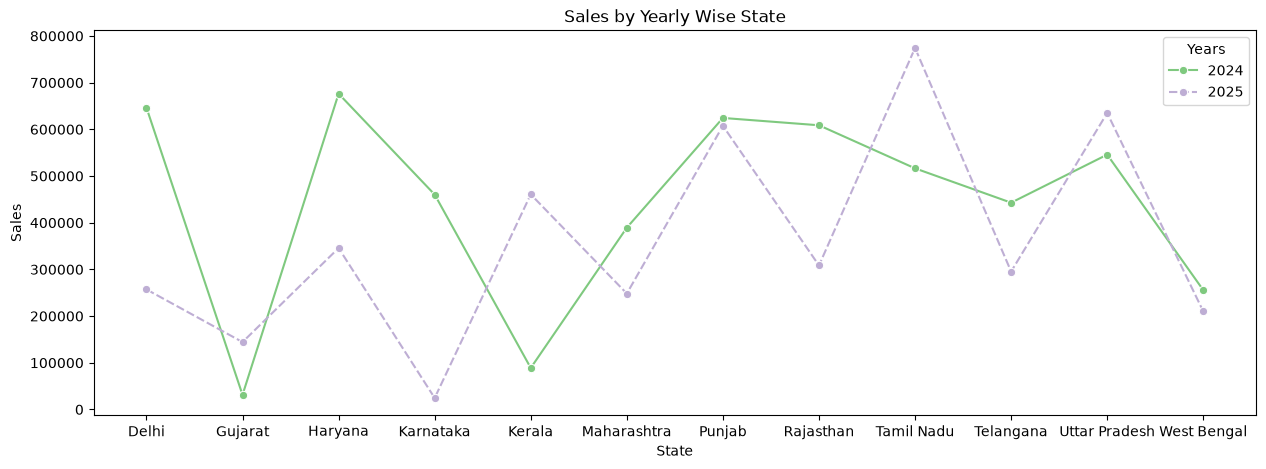

In [27]:
plt.figure(figsize=(15,5))
sns.lineplot(x=State_yearly_sales['State'],y=State_yearly_sales['Sales'],hue=State_yearly_sales['Years'],style=State_yearly_sales['Years'],palette='Accent'
            ,markers=['o','o'])
plt.title("Sales by Yearly Wise State")
plt.show()

Sales by Brand Represent on Pie Chart

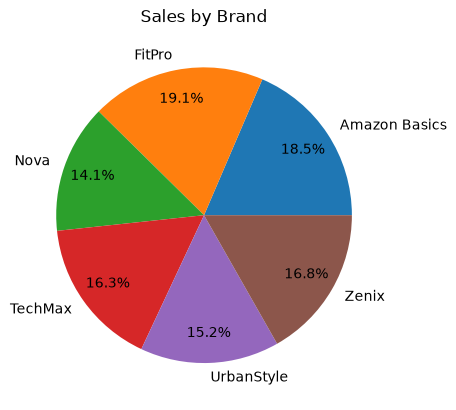

In [28]:
plt.pie(brand_sales['Sales'],labels=brand_sales['Brand'],autopct='%1.1f%%',pctdistance=0.80)
plt.title('Sales by Brand')
plt.show()

## Represent on Barplot Yearly Sales

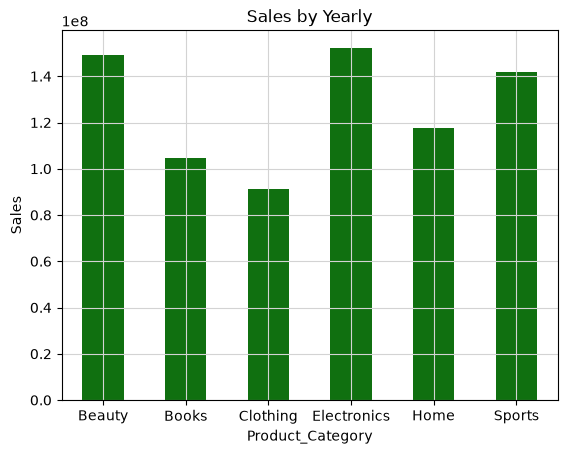

In [29]:
sns.barplot(x='Product_Category',y="Sales",data=Category_Sales,width=0.5,color='g' )
plt.title("Sales by Yearly")
plt.grid(color="lightgray")
plt.show()

## Represent on Horizintel Barplot City Sales

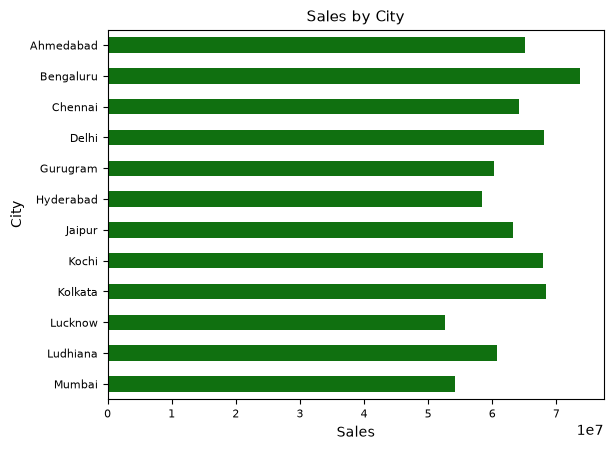

In [30]:
sns.barplot(x='Sales',y="City",data=City_Sales,width=0.5,color='g' )
plt.title("Sales by City" , fontsize=11)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

## Count of Return Orders By Reason Represent on Stackplot 

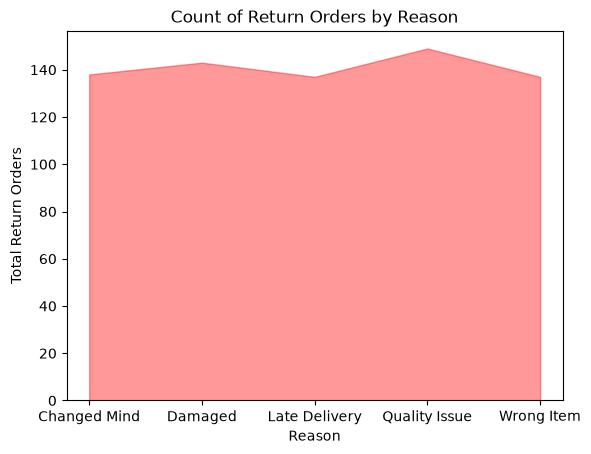

In [31]:
plt.stackplot(ReasonReturn_Count['Reason'],ReasonReturn_Count['Return_Orders'],alpha=0.4,color="r")
plt.xlabel("Reason")
plt.ylabel('Total Return Orders')
plt.title("Count of Return Orders by Reason")
plt.show()

## Represent on Lineplot Show the Total Quantity for Each Product

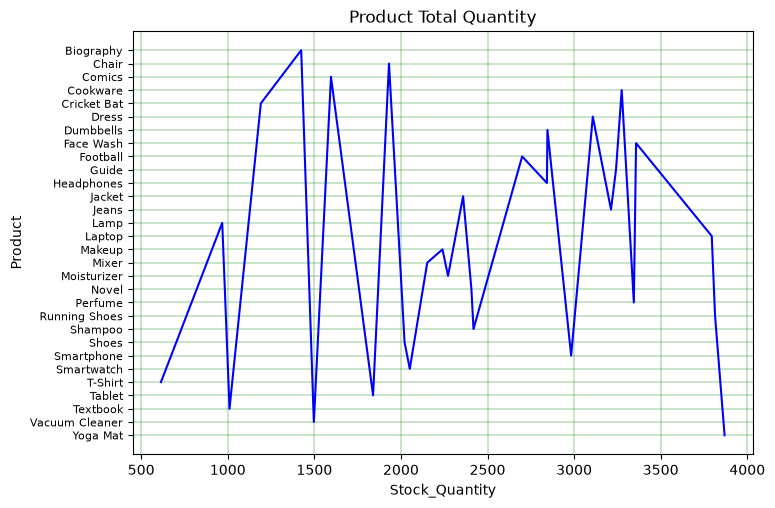

In [46]:
plt.figure(figsize=(8,5.5))
sns.lineplot(x='Stock_Quantity',y='Product',data=Product_Stock,color="b")
plt.yticks(fontsize=8)
plt.grid(linewidth=0.3,color="g")
plt.title("Product Total Quantity")
plt.show()

## Count of Total Payments by Payment Status

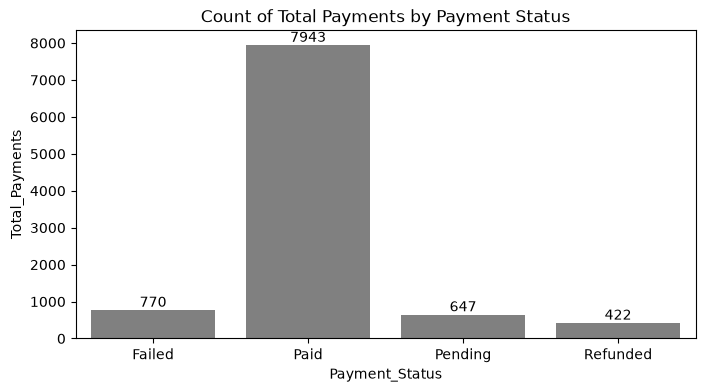

In [50]:
plt.figure(figsize=(8,4))
ax = sns.barplot(PaymentStatus_Count,x="Payment_Status",y="Total_Payments",color='gray')
plt.title("Count of Total Payments by Payment Status")
ax.bar_label(ax.containers[0])
plt.show()